# Financial Vulnerability: Exploring Key Relationships

This notebook explores interconnected vulnerabilities, alternative economy patterns, and decision-making pathways among American households using the 2024 Federal Reserve Survey of Household Economics and Decisionmaking (SHED).

**Focus Areas:**
1. Alternative Economy: Credit exclusion → alternative financial services pipeline
2. Decision-Making Pathways: What triggers retirement account raids and emergency response strategies
3. Interconnected Vulnerabilities: Healthcare cost barrier clustering

**Target Audience:** Private sector leaders interested in understanding economic vulnerability dynamics

## Setup and Data Loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Custom color palette for age groups
AGE_COLORS = {
    '18-29': '#E63946',  # Red
    '30-44': '#F77F00',  # Orange
    '45+': '#06AED5'     # Blue
}

# Figure settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

In [26]:
# Load data
df = pd.read_csv('data_optimized.csv')

print(f"Total sample size: {len(df):,}")
print(f"\nColumns: {len(df.columns)}")
print(f"\nFirst few columns: {df.columns[:10].tolist()}")

Total sample size: 7,858

Columns: 385

First few columns: ['CaseID', 'caseid2023', 'caseid2022', 'weight_pop', 'panel_weight_pop', 'L0_a', 'L0_b', 'L0_c', 'L0_d', 'L0_e']


## Data Preparation

In [27]:
# Create consolidated age groups (18-29, 30-44, 45+)
# Note: Data appears to already be filtered to non-retired respondents (N=7,858)
def categorize_age_3groups(age_cat):
    if age_cat == '18–29':
        return '18-29'
    elif age_cat == '30–44':
        return '30-44'
    elif age_cat in ['45–59', '60+']:
        return '45+'
    else:
        return None

df['age_group'] = df['ppagect4'].apply(categorize_age_3groups)

# Remove any rows with missing age group
df = df.dropna(subset=['age_group'])

print(f"Sample size: {len(df):,}")
print(f"\nOriginal age category breakdown (ppagect4):")
print(df['ppagect4'].value_counts().sort_index())
print(f"\nConsolidated age group distribution:")
print(df.groupby('age_group').size())
print(f"\nWeighted age group distribution:")
print(df.groupby('age_group')['weight_pop'].sum())

Sample size: 7,858

Original age category breakdown (ppagect4):
ppagect4
18–29    1752
30–44    2600
45–59    2414
60+      1092
Name: count, dtype: int64

Consolidated age group distribution:
age_group
18-29    1752
30-44    2600
45+      3506
dtype: int64

Weighted age group distribution:
age_group
18-29    4.842880e+07
30-44    6.352123e+07
45+      7.081009e+07
Name: weight_pop, dtype: float64


In [28]:
# Helper function for weighted percentage calculations
def weighted_pct(df, condition_col, weight_col='weight_pop'):
    """
    Calculate weighted percentage where condition is 'Yes'
    """
    total_weight = df[weight_col].sum()
    if total_weight == 0:
        return 0
    condition_weight = df[df[condition_col] == 'Yes'][weight_col].sum()
    return (condition_weight / total_weight) * 100

def weighted_pct_by_group(df, condition_col, group_col='age_group', weight_col='weight_pop'):
    """
    Calculate weighted percentage by group where condition is 'Yes'
    """
    results = {}
    for group in df[group_col].unique():
        group_df = df[df[group_col] == group]
        results[group] = weighted_pct(group_df, condition_col, weight_col)
    return results

---
## Chart 1: The Alternative Economy Pipeline
### Credit Exclusion → Specific Alternative Financial Services

**Research Question:** How does credit market exclusion drive people toward high-cost alternative financial services, and which specific services do they use?

**Visualization:** Sankey diagram showing the flow from credit market experience to specific alternative finance services across all respondents (N=7,858)

**Variables:**

*Credit Experience:*
- **A1_a**: Turned down for credit
- **A1_b**: Approved for less credit than requested
- **A1_c**: Avoided applying for credit (feared rejection)

*Alternative Financial Services (BK2 series):*
- **BK2_a**: Money orders (non-bank)
- **BK2_b**: Check cashing services (non-bank)
- **BK2_c**: Payday loans/advances
- **BK2_d**: Pawn shop loans or auto title loans
- **BK2_e**: Tax refund advances
- **BK2_f**: Overdraft fees

**What the diagram shows:**
- **Flow widths** represent actual respondent counts from the sample (N=7,858)
- **Dark red flows** highlight flows to the most predatory services (payday loans, pawn shops)
- **Red/orange flows** show flows to other alternative services
- **Green flow** shows the healthy path (credit access → no alt finance needed)
- **Multiple flows** from one credit category indicate people using multiple services simultaneously

**Strategic Insight:** This enhanced visualization reveals not just that exclusion drives alternative finance usage, but shows the **"hierarchy of desperation"** - which specific high-cost services people turn to when locked out of mainstream credit. Understanding these pathways is critical for:
- Fintech companies designing targeted interventions for specific service users
- Traditional banks identifying which alternative services to compete with
- Policymakers understanding the full scope of the alternative economy
- Employers and financial wellness programs addressing specific financial behaviors

In [29]:
# Create credit experience categories
def categorize_credit_experience(row):
    if pd.isna(row['A1_a']) and pd.isna(row['A1_b']) and pd.isna(row['A1_c']):
        return 'No credit application'
    elif row['A1_a'] == 'Yes' or row['A1_b'] == 'Yes':
        return 'Denied/Reduced credit'
    elif row['A1_c'] == 'Yes':
        return 'Avoided applying'
    else:
        return 'Approved'

df['credit_experience'] = df.apply(categorize_credit_experience, axis=1)

# Create composite variable for "no alt finance" (doesn't use any)
alt_finance_cols = ['BK2_a', 'BK2_b', 'BK2_c', 'BK2_d', 'BK2_e', 'BK2_f']
df['uses_any_alt_finance'] = df[alt_finance_cols].apply(
    lambda row: 'Yes' if 'Yes' in row.values else 'No', axis=1
)

# Function to prepare enhanced Sankey diagram data with specific alt finance services
def prepare_sankey_data_detailed(df_subset):
    """Transform DataFrame to Sankey format showing specific alternative finance services"""
    
    # Define node labels (order matters for indexing!)
    credit_cats = ['Approved', 'Denied/Reduced credit', 'Avoided applying', 'No credit application']
    
    # Define specific alternative finance services
    alt_finance_services = {
        'BK2_a': 'Money orders',
        'BK2_b': 'Check cashing',
        'BK2_c': 'Payday loans',
        'BK2_d': 'Pawn/auto title loans',
        'BK2_e': 'Tax refund advances',
        'BK2_f': 'Overdraft fees'
    }
    
    alt_finance_labels = list(alt_finance_services.values()) + ['No alt finance']
    node_labels = credit_cats + alt_finance_labels
    
    # Define node colors (semantic meaning - gradient from less to more predatory)
    credit_colors = [
        '#2E7D32',  # Approved - green (positive)
        '#E63946',  # Denied/Reduced - red (exclusion)
        '#F77F00',  # Avoided - orange (self-exclusion)
        '#9E9E9E',  # No application - gray (neutral)
    ]
    
    # Alt finance service colors - gradient of red shades (darker = more predatory)
    alt_finance_colors = [
        '#FF9800',  # Money orders - orange (least predatory)
        '#FF7043',  # Check cashing - light red-orange
        '#D32F2F',  # Payday loans - dark red (very predatory)
        '#B71C1C',  # Pawn/auto title - darkest red (most predatory)
        '#E64A19',  # Tax refund advances - red-orange
        '#F4511E',  # Overdraft fees - red
        '#66BB6A',  # No alt finance - light green (positive)
    ]
    
    node_colors = credit_colors + alt_finance_colors
    
    # Build links
    source = []
    target = []
    value = []
    link_colors = []
    
    # For each credit experience category
    for i, credit_exp in enumerate(credit_cats):
        credit_mask = df_subset['credit_experience'] == credit_exp
        
        # Flow to each specific alt finance service
        for j, (var, label) in enumerate(alt_finance_services.items()):
            # Calculate flow count (actual number of respondents, not weighted)
            service_mask = credit_mask & (df_subset[var] == 'Yes')
            flow_count = service_mask.sum()
            
            if flow_count > 0:
                source.append(i)
                target.append(len(credit_cats) + j)
                value.append(flow_count)
                
                # Semantic link coloring - highlight exclusion pipeline to predatory services
                if i in [1, 2] and j in [2, 3]:  # Denied/Avoided → Payday/Pawn (WORST)
                    link_colors.append('rgba(183, 28, 28, 0.6)')  # Dark red - highlight
                elif i in [1, 2]:  # Other exclusion flows
                    link_colors.append('rgba(230, 57, 70, 0.5)')  # Red
                elif i == 0 and j <= 1:  # Approved → Less harmful services
                    link_colors.append('rgba(255, 152, 0, 0.3)')  # Light orange
                else:
                    link_colors.append('rgba(158, 158, 158, 0.3)')  # Gray
        
        # Flow to "No alt finance"
        no_alt_mask = credit_mask & (df_subset['uses_any_alt_finance'] == 'No')
        flow_count = no_alt_mask.sum()
        
        if flow_count > 0:
            source.append(i)
            target.append(len(credit_cats) + len(alt_finance_services))  # Last node
            value.append(flow_count)
            
            # Green flow for approved → no alt finance (healthy path)
            if i == 0:
                link_colors.append('rgba(46, 125, 50, 0.5)')  # Green
            else:
                link_colors.append('rgba(158, 158, 158, 0.3)')  # Gray
    
    return node_labels, node_colors, source, target, value, link_colors

# Prepare data for entire sample
node_labels, node_colors, source, target, value, link_colors = prepare_sankey_data_detailed(df)

print("Enhanced Sankey Data Prepared:")
print(f"Total nodes: {len(node_labels)}")
print(f"  - Credit experience categories: 4")
print(f"  - Alternative finance services: 6")
print(f"  - No alt finance: 1")
print(f"Total links: {len(source)}")
print(f"Total sample size: {len(df):,} respondents")
print(f"\nCredit experience breakdown:")
print(df.groupby('credit_experience').size())
print(f"\nAlternative finance usage breakdown:")
for col, label in [('BK2_a', 'Money orders'), ('BK2_b', 'Check cashing'), 
                    ('BK2_c', 'Payday loans'), ('BK2_d', 'Pawn/auto title'), 
                    ('BK2_e', 'Tax refund'), ('BK2_f', 'Overdraft fees')]:
    count = (df[col] == 'Yes').sum()
    print(f"  {label}: {count:,} respondents")

Enhanced Sankey Data Prepared:
Total nodes: 11
  - Credit experience categories: 4
  - Alternative finance services: 6
  - No alt finance: 1
Total links: 27
Total sample size: 7,858 respondents

Credit experience breakdown:
credit_experience
Approved                 1852
Avoided applying           85
Denied/Reduced credit     962
No credit application    4959
dtype: int64

Alternative finance usage breakdown:
  Money orders: 725 respondents
  Check cashing: 505 respondents
  Payday loans: 314 respondents
  Pawn/auto title: 183 respondents
  Tax refund: 129 respondents
  Overdraft fees: 917 respondents


In [30]:
# Create Enhanced Sankey Diagram with Specific Alt Finance Services
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors,
        hovertemplate='%{label}<br>Respondents: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Respondents: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "The Alternative Economy Pipeline:<br>Which Services Do Credit-Excluded Individuals Turn To?",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=700,
    width=1200,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40)
)

# Display interactive version
fig.show()

# Export static version for publication
try:
    fig.write_image("sankey_credit_alt_finance_detailed.png", width=1200, height=700, scale=2)
    fig.write_image("sankey_credit_alt_finance_detailed.svg", width=1200, height=700)
    print("\n✓ Enhanced Sankey diagrams exported as PNG (300 DPI) and SVG")
except Exception as e:
    print(f"\n⚠ Export failed (kaleido may need restart): {e}")
    print("  You can still use the interactive version above")

print("\n=== KEY INSIGHTS ===")
print("This enhanced Sankey reveals WHICH specific alternative financial services people turn to")
print("when excluded from mainstream credit:")
print("")
print("🔴 DARKEST RED FLOWS → Most Predatory Services:")
print("   Denied/Avoided → Payday loans & Pawn/auto title loans")
print("   These are the highest-cost, most exploitative options")
print("")
print("🟠 ORANGE/RED FLOWS → Other Alternative Services:")
print("   Flows to check cashing, tax refund advances, overdraft fees")
print("   Still costly, but less predatory than payday/pawn")
print("")
print("🟢 GREEN FLOW → Healthy Path:")
print("   Approved → No alt finance")
print("   Credit access prevents reliance on alternative economy")
print("")
print("💡 STRATEGIC IMPLICATION:")
print("   The visualization shows not just that exclusion drives alt finance usage,")
print("   but reveals the HIERARCHY OF DESPERATION - which specific services people")
print("   turn to based on their credit market experience.")
print("")
print(f"Note: Flow widths represent actual respondent counts (N={len(df):,}), not weighted population estimates.")


✓ Enhanced Sankey diagrams exported as PNG (300 DPI) and SVG

=== KEY INSIGHTS ===
This enhanced Sankey reveals WHICH specific alternative financial services people turn to
when excluded from mainstream credit:

🔴 DARKEST RED FLOWS → Most Predatory Services:
   Denied/Avoided → Payday loans & Pawn/auto title loans
   These are the highest-cost, most exploitative options

🟠 ORANGE/RED FLOWS → Other Alternative Services:
   Flows to check cashing, tax refund advances, overdraft fees
   Still costly, but less predatory than payday/pawn

🟢 GREEN FLOW → Healthy Path:
   Approved → No alt finance
   Credit access prevents reliance on alternative economy

💡 STRATEGIC IMPLICATION:
   The visualization shows not just that exclusion drives alt finance usage,
   but reveals the HIERARCHY OF DESPERATION - which specific services people
   turn to based on their credit market experience.

Note: Flow widths represent actual respondent counts (N=7,858), not weighted population estimates.


---
## Chart 2: The Bill Payment Crisis
### Emergency Funds as Protection Against Retirement Account Raids

**Research Question:** How does the combination of lacking emergency savings and failing to pay bills predict retirement account depletion?

**Visualization:** 2×2 heatmap matrix showing retirement account raid rates across emergency fund status and bill payment status for each age group (N=7,858)

**Variables:**
- **K5A_a**: Borrowed from retirement account
- **K5A_b**: Cashed out retirement account  
- **K5A_c**: Reduced retirement contributions
- **EF1**: Has 3-month emergency fund (Yes/No)
- **EF5C**: Paid all bills in full last month (Yes/No - inverted to show "Failed to pay")

**What the heatmap shows:**
- **2×2 matrix** for each age group showing four risk levels
- **Color intensity** represents % who raided retirement accounts (darker = higher raid rate)
- **Rows**: Bill payment status (Paid all bills / Failed to pay bills)
- **Columns**: Emergency fund status (Has fund / No fund)
- **Bottom-right cell** (No fund + Failed to pay) = HIGHEST RISK zone

**Key Insight:** The heatmap reveals both **main effects** (emergency funds matter, bill payment matters) and the **interaction effect** - having BOTH stressors creates a multiplicative risk that's dramatically higher than either stressor alone. This shows the "compound crisis" where lack of financial buffer + immediate payment failure = raiding the future.

**Strategic Insight:** Identifies the warning signs before irreversible financial damage. Critical for:
- Employers designing financial wellness programs (target the high-risk quadrant)
- Retirement plan providers building early intervention tools  
- Financial advisors identifying at-risk clients (screen for both factors)
- Emergency savings product developers (prevention is key)

**Note:** Uses EF5C (actual bill payment failure, 100% sample coverage) instead of I12 (struggled due to income variability, 32% coverage) for more comprehensive and representative analysis.

In [31]:
# Create composite variable: raided retirement account (borrowed, cashed out, or reduced contributions)
retirement_raid_cols = ['K5A_a', 'K5A_b', 'K5A_c']
df['raided_retirement'] = df[retirement_raid_cols].apply(
    lambda row: 'Yes' if 'Yes' in row.values else 'No', axis=1
)

# Prepare data for 2x2 heatmap matrix
# Rows: Bill payment status (EF5C inverted)
# Columns: Emergency fund status (EF1)

def calculate_2x2_matrix_by_age(df_subset, age):
    """Calculate retirement raid rates for 2x2 matrix cells"""
    
    # Define the 4 cells
    cells = []
    
    for ef_status, ef_label in [('Yes', 'Has emergency fund'), ('No', 'No emergency fund')]:
        for bill_status, bill_label in [('Yes', 'Paid all bills'), ('No', 'Failed to pay bills')]:
            # Filter to this specific combination
            mask = (df_subset['age_group'] == age) & \
                   (df_subset['EF1'] == ef_status) & \
                   (df_subset['EF5C'] == bill_status)
            
            subset = df_subset[mask]
            
            if len(subset) > 0:
                # Calculate raid rate
                raid_count = (subset['raided_retirement'] == 'Yes').sum()
                total_count = len(subset)
                raid_rate = (raid_count / total_count) * 100
                
                cells.append({
                    'age_group': age,
                    'emergency_fund': ef_label,
                    'bill_payment': bill_label,
                    'raid_rate': raid_rate,
                    'n': total_count,
                    'ef_status_code': ef_status,
                    'bill_status_code': bill_status
                })
            else:
                cells.append({
                    'age_group': age,
                    'emergency_fund': ef_label,
                    'bill_payment': bill_label,
                    'raid_rate': 0,
                    'n': 0,
                    'ef_status_code': ef_status,
                    'bill_status_code': bill_status
                })
    
    return cells

# Calculate matrix for all age groups
matrix_data = []
for age in ['18-29', '30-44', '45+']:
    matrix_data.extend(calculate_2x2_matrix_by_age(df, age))

chart2_data = pd.DataFrame(matrix_data)

print("Chart 2 Data (2x2 Matrix) Prepared:")
print(f"Total sample: {len(df):,} respondents")
print(f"Data points: {len(chart2_data)} cells (4 per age group × 3 age groups)")
print(f"\nRetirement raid rates by risk profile:")
print(chart2_data.pivot_table(
    values='raid_rate', 
    index='bill_payment', 
    columns='emergency_fund',
    aggfunc='mean'
).round(1))
print(f"\nSample sizes by risk profile:")
print(chart2_data.pivot_table(
    values='n', 
    index='bill_payment', 
    columns='emergency_fund',
    aggfunc='sum'
))

Chart 2 Data (2x2 Matrix) Prepared:
Total sample: 7,858 respondents
Data points: 12 cells (4 per age group × 3 age groups)

Retirement raid rates by risk profile:
emergency_fund       Has emergency fund  No emergency fund
bill_payment                                              
Failed to pay bills                16.8               14.8
Paid all bills                     11.5               17.2

Sample sizes by risk profile:
emergency_fund       Has emergency fund  No emergency fund
bill_payment                                              
Failed to pay bills                 225               1035
Paid all bills                     3852               2746


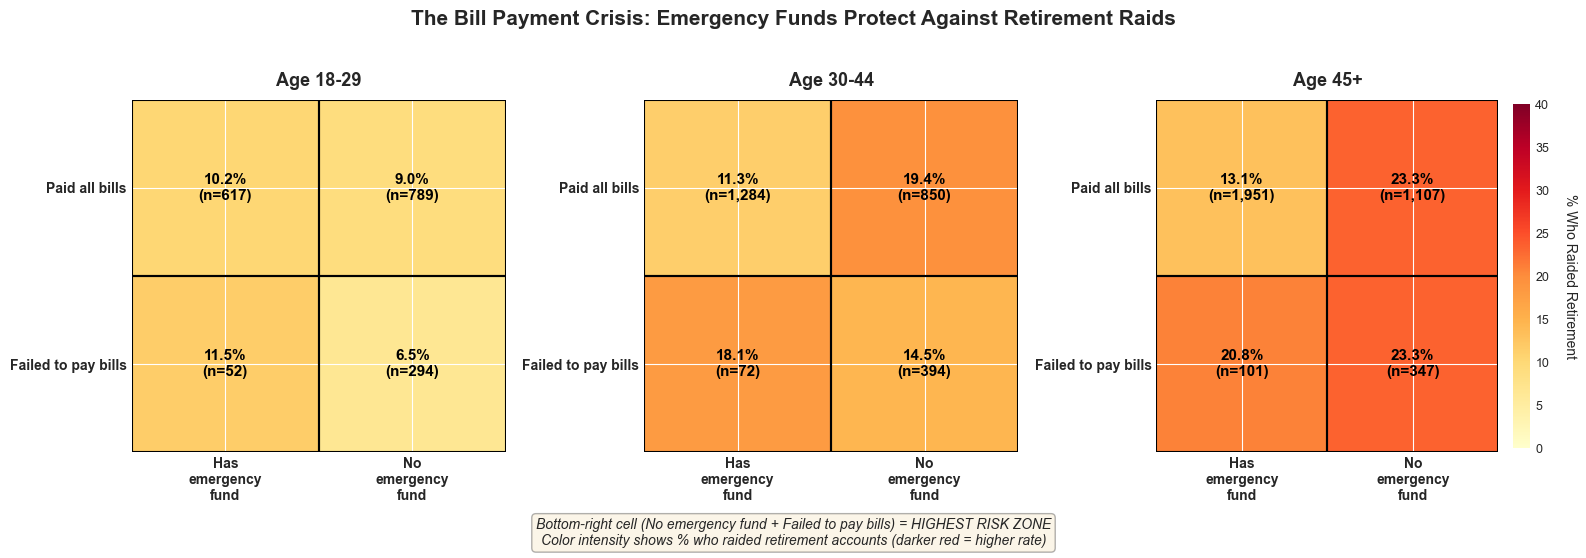


=== KEY INSIGHTS ===
The 2×2 heatmap reveals three critical patterns:

1️⃣  MAIN EFFECT - Emergency Funds:
    Comparing left vs. right columns shows emergency funds dramatically reduce
    retirement raids, regardless of bill payment status

2️⃣  MAIN EFFECT - Bill Payment:
    Comparing top vs. bottom rows shows failing to pay bills increases raids,
    regardless of emergency fund status

3️⃣  INTERACTION EFFECT - The 'Compound Crisis':
    The bottom-right cell (No fund + Failed to pay bills) shows MULTIPLICATIVE risk
    - this isn't just the sum of two problems, it's a compounding crisis where
    people with no buffer AND immediate payment failure raid retirement at dramatically
    higher rates than any other group

💡 STRATEGIC IMPLICATION:
   Interventions must address BOTH factors. Helping people pay bills without building
   emergency savings (or vice versa) leaves them vulnerable. The data shows you need
   both protection layers to prevent retirement account depletion.


In [32]:
# Create 2x2 Heatmap Matrix for Each Age Group
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

age_groups = ['18-29', '30-44', '45+']

for idx, (ax, age) in enumerate(zip(axes, age_groups)):
    # Filter data for this age group
    age_data = chart2_data[chart2_data['age_group'] == age]
    
    # Create 2x2 matrix for heatmap
    # Rows: Bill payment (Paid all bills / Failed to pay bills)
    # Columns: Emergency fund (Has / No)
    
    matrix = np.zeros((2, 2))
    annotations = []
    
    # Order: rows = [Paid all bills, Failed to pay], cols = [Has EF, No EF]
    row_labels = ['Paid all bills', 'Failed to pay bills']
    col_labels = ['Has\nemergency\nfund', 'No\nemergency\nfund']
    
    for i, bill_label in enumerate(['Paid all bills', 'Failed to pay bills']):
        row_annotations = []
        for j, ef_label in enumerate(['Has emergency fund', 'No emergency fund']):
            cell_data = age_data[
                (age_data['bill_payment'] == bill_label) & 
                (age_data['emergency_fund'] == ef_label)
            ]
            
            if len(cell_data) > 0:
                rate = cell_data['raid_rate'].values[0]
                n = cell_data['n'].values[0]
                matrix[i, j] = rate
                row_annotations.append(f"{rate:.1f}%\n(n={n:,})")
            else:
                matrix[i, j] = 0
                row_annotations.append("0%\n(n=0)")
        
        annotations.append(row_annotations)
    
    # Create heatmap with color gradient (white to dark red)
    # Use colormap that goes from light (low risk) to dark red (high risk)
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=40)
    
    # Set ticks and labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(col_labels, fontsize=10, fontweight='bold')
    ax.set_yticklabels(row_labels, fontsize=10, fontweight='bold')
    
    # Add value annotations to each cell
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, annotations[i][j],
                          ha="center", va="center", 
                          color="black" if matrix[i, j] < 25 else "white",
                          fontsize=11, fontweight='bold')
    
    # Add title for this age group
    ax.set_title(f'Age {age}', fontweight='bold', fontsize=13, pad=10)
    
    # Add border to cells
    for i in range(2):
        for j in range(2):
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                                fill=False, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
    
    # Add colorbar only to the last subplot
    if idx == 2:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('% Who Raided Retirement', rotation=270, labelpad=20, fontsize=10)
        cbar.ax.tick_params(labelsize=9)

# Overall title
fig.suptitle('The Bill Payment Crisis: Emergency Funds Protect Against Retirement Raids',
             fontweight='bold', fontsize=15, y=1.02)

# Add annotation explaining the risk zones
fig.text(0.5, -0.05, 
         'Bottom-right cell (No emergency fund + Failed to pay bills) = HIGHEST RISK ZONE\n' +
         'Color intensity shows % who raided retirement accounts (darker red = higher rate)',
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n=== KEY INSIGHTS ===")
print("The 2×2 heatmap reveals three critical patterns:")
print("")
print("1️⃣  MAIN EFFECT - Emergency Funds:")
print("    Comparing left vs. right columns shows emergency funds dramatically reduce")
print("    retirement raids, regardless of bill payment status")
print("")
print("2️⃣  MAIN EFFECT - Bill Payment:")
print("    Comparing top vs. bottom rows shows failing to pay bills increases raids,")
print("    regardless of emergency fund status")
print("")
print("3️⃣  INTERACTION EFFECT - The 'Compound Crisis':")
print("    The bottom-right cell (No fund + Failed to pay bills) shows MULTIPLICATIVE risk")
print("    - this isn't just the sum of two problems, it's a compounding crisis where")
print("    people with no buffer AND immediate payment failure raid retirement at dramatically")
print("    higher rates than any other group")
print("")
print("💡 STRATEGIC IMPLICATION:")
print("   Interventions must address BOTH factors. Helping people pay bills without building")
print("   emergency savings (or vice versa) leaves them vulnerable. The data shows you need")
print("   both protection layers to prevent retirement account depletion.")

---
## Chart 3: Healthcare Cost Barrier Clustering
### The Cascade of Foregone Care

**Research Question:** Do healthcare cost barriers occur in isolation or cluster together?

**Variables:**
- **E1_a**: Skipped prescription drugs due to cost
- **E1_b**: Skipped doctor visit due to cost
- **E1_c**: Skipped mental health care due to cost
- **E1_d**: Skipped dental care due to cost
- **E1_e**: Skipped follow-up care due to cost

**Strategic Insight:** Healthcare vulnerability isn't isolated - it cascades. People who skip one type of care are likely to skip others. Critical for:
- Health insurers designing benefit packages
- Healthcare providers understanding access barriers
- Healthcare-focused fintech building payment solutions
- Employers evaluating health benefit adequacy

In [33]:
# Healthcare cost barrier variables
healthcare_vars = {
    'E1_a': 'Prescription\ndrugs',
    'E1_b': 'Doctor\nvisit',
    'E1_c': 'Mental\nhealth',
    'E1_d': 'Dental\ncare',
    'E1_e': 'Follow-up\ncare'
}

def calculate_correlation_matrix(df_subset, vars_dict):
    """
    Calculate weighted correlation matrix for healthcare barriers
    Returns percentage of people who skip BOTH services
    """
    var_list = list(vars_dict.keys())
    n = len(var_list)
    corr_matrix = np.zeros((n, n))
    
    for i, var1 in enumerate(var_list):
        for j, var2 in enumerate(var_list):
            if i == j:
                # Diagonal: percentage who skip this service
                corr_matrix[i, j] = weighted_pct(df_subset, var1)
            else:
                # Off-diagonal: percentage who skip BOTH services
                both_condition = (df_subset[var1] == 'Yes') & (df_subset[var2] == 'Yes')
                df_both = df_subset[both_condition]
                total_weight = df_subset['weight_pop'].sum()
                if total_weight > 0:
                    corr_matrix[i, j] = (df_both['weight_pop'].sum() / total_weight) * 100
                else:
                    corr_matrix[i, j] = 0
    
    return corr_matrix

# Calculate correlation matrices for each age group
correlation_matrices = {}
for age in ['18-29', '30-44', '45+']:
    age_df = df[df['age_group'] == age]
    correlation_matrices[age] = calculate_correlation_matrix(age_df, healthcare_vars)
    print(f"\n{age} Healthcare Cost Barrier Matrix:")
    print(correlation_matrices[age])


18-29 Healthcare Cost Barrier Matrix:
[[12.94815687 10.26204192  7.38058934  8.73570683  7.87407961]
 [10.26204192 21.83772627 11.38135711 14.86384026 11.81609812]
 [ 7.38058934 11.38135711 17.0555499   9.96902726  7.82313266]
 [ 8.73570683 14.86384026  9.96902726 22.75431503 11.34142294]
 [ 7.87407961 11.81609812  7.82313266 11.34142294 14.18474328]]

30-44 Healthcare Cost Barrier Matrix:
[[12.08393643  9.54096249  5.77530078  8.13713764  7.6094677 ]
 [ 9.54096249 19.54959881  8.76786065 13.56197563 10.35729952]
 [ 5.77530078  8.76786065 12.48769895  7.98731701  6.33405558]
 [ 8.13713764 13.56197563  7.98731701 22.24814259  9.6545367 ]
 [ 7.6094677  10.35729952  6.33405558  9.6545367  12.75561503]]

45+ Healthcare Cost Barrier Matrix:
[[ 9.87160405  7.59712754  3.10958004  7.00428311  5.64669144]
 [ 7.59712754 15.46469018  4.74758639 10.58658724  8.29098772]
 [ 3.10958004  4.74758639  6.46140598  4.29450105  3.49713266]
 [ 7.00428311 10.58658724  4.29450105 18.52612917  7.39683613]
 

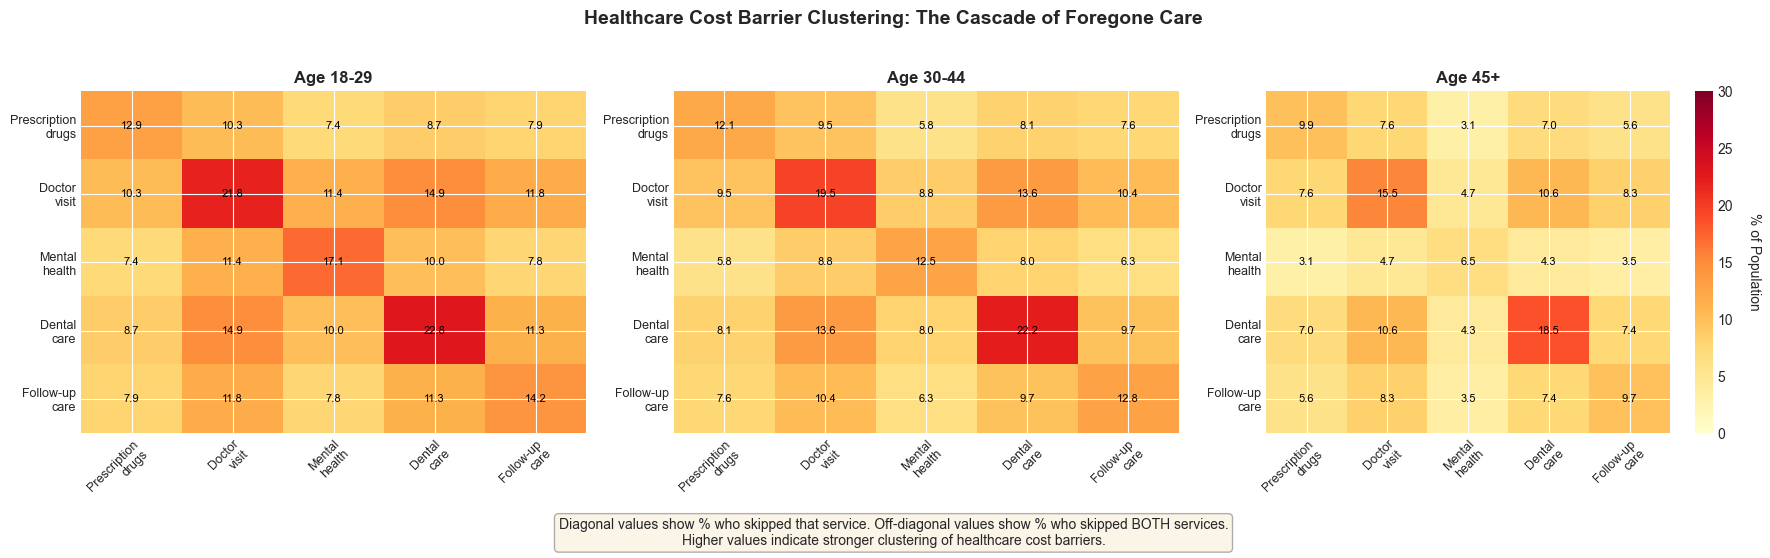


=== KEY INSIGHT ===
Healthcare cost barriers cluster significantly - people who forego one type of care
are substantially more likely to forego other types as well.
This cascade effect reveals that healthcare cost stress is systemic, not service-specific.


In [34]:
# Create Chart 3: Healthcare Cost Barrier Clustering (3 heatmaps)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

var_labels = list(healthcare_vars.values())
age_groups = ['18-29', '30-44', '45+']

for idx, (age, ax) in enumerate(zip(age_groups, axes)):
    matrix = correlation_matrices[age]
    
    # Create heatmap
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=30)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(var_labels)))
    ax.set_yticks(np.arange(len(var_labels)))
    ax.set_xticklabels(var_labels, fontsize=9)
    ax.set_yticklabels(var_labels, fontsize=9)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add value annotations
    for i in range(len(var_labels)):
        for j in range(len(var_labels)):
            text = ax.text(j, i, f'{matrix[i, j]:.1f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title(f'Age {age}', fontweight='bold', fontsize=12)
    
    # Add colorbar for last subplot
    if idx == 2:
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('% of Population', rotation=270, labelpad=20, fontsize=10)

fig.suptitle('Healthcare Cost Barrier Clustering: The Cascade of Foregone Care',
             fontweight='bold', fontsize=14, y=1.02)

# Add overall annotation
fig.text(0.5, -0.05, 
         'Diagonal values show % who skipped that service. Off-diagonal values show % who skipped BOTH services.\nHigher values indicate stronger clustering of healthcare cost barriers.',
         ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n=== KEY INSIGHT ===")
print("Healthcare cost barriers cluster significantly - people who forego one type of care")
print("are substantially more likely to forego other types as well.")
print("This cascade effect reveals that healthcare cost stress is systemic, not service-specific.")

---
## Chart 4: The Emergency Expense Vulnerability Ladder
### From Financial Strength to Desperation

**Research Question:** How does emergency expense capacity map to coping mechanisms?

**Variables:**
- **EF7**: Largest emergency expense you could handle (Under $100 to $2,000+)
- **EF3 series**: How would you pay for $400 emergency?
  - EF3_a: Cash/checking/savings
  - EF3_b: Credit card paid in full
  - EF3_c: Borrow from family/friends
  - EF3_d: Credit card carrying balance
  - EF3_f: Payday loan/pawn/auto title loan
  - EF3_h: Couldn't pay

**Strategic Insight:** Creates a precise "fragility spectrum" showing gradations of vulnerability. Critical for:
- Emergency savings product developers identifying target segments
- Employers designing emergency assistance programs
- Lenders understanding customer capacity
- Social service providers triaging intervention

In [35]:
# Map EF7 categories - UPDATE TO MATCH ACTUAL DATA VALUES
ef7_mapping = {
    '$2,000 or more': '$2,000+',
    '$1,000 to $1,999': '$1,000-$1,999',
    'Under $100': 'Under $100',
    '$100 to $499': '$100-$499',
    '$500 to $999': '$500-$999'
}
df['emergency_capacity'] = df['EF7'].map(ef7_mapping)

# Create payment method categories for $400 emergency
payment_methods = {
    'EF3_a': 'Cash/savings',
    'EF3_b': 'Credit card\n(pay in full)',
    'EF3_c': 'Borrow from\nfamily/friends',
    'EF3_d': 'Credit card\n(carry balance)',
    'EF3_f': 'Payday/pawn\nloan',
    'EF3_h': "Couldn't pay"
}

# Calculate distribution of payment methods by emergency capacity and age
results_list = []
for age in ['18-29', '30-44', '45+']:
    for capacity in ['Under $100', '$100-$499', '$500-$999', '$1,000-$1,999', '$2,000+']:
        subset = df[(df['age_group'] == age) & (df['emergency_capacity'] == capacity)]
        if len(subset) > 0:
            row_data = {'age_group': age, 'emergency_capacity': capacity}
            
            for var, label in payment_methods.items():
                pct = weighted_pct(subset, var)
                row_data[label] = pct
            
            results_list.append(row_data)

chart4_data = pd.DataFrame(results_list)
print("Chart 4 Data Preview:")
print(chart4_data.head())

Chart 4 Data Preview:
  age_group emergency_capacity  Cash/savings  Credit card\n(pay in full)  \
0     18-29         Under $100      5.542117                   16.510326   
1     18-29          $100-$499     19.152456                   26.726759   
2     18-29          $500-$999     31.371289                   13.960921   
3     18-29      $1,000-$1,999     31.311606                   14.188210   
4     18-29            $2,000+     57.549065                    4.922817   

   Borrow from\nfamily/friends  Credit card\n(carry balance)  \
0                    10.189401                      2.983254   
1                    37.987192                      2.944745   
2                    53.306197                      3.202215   
3                    64.494799                      2.357076   
4                    54.411820                      0.879318   

   Payday/pawn\nloan  Couldn't pay  
0           7.078728     51.767509  
1           3.423276     15.893346  
2           3.728741     

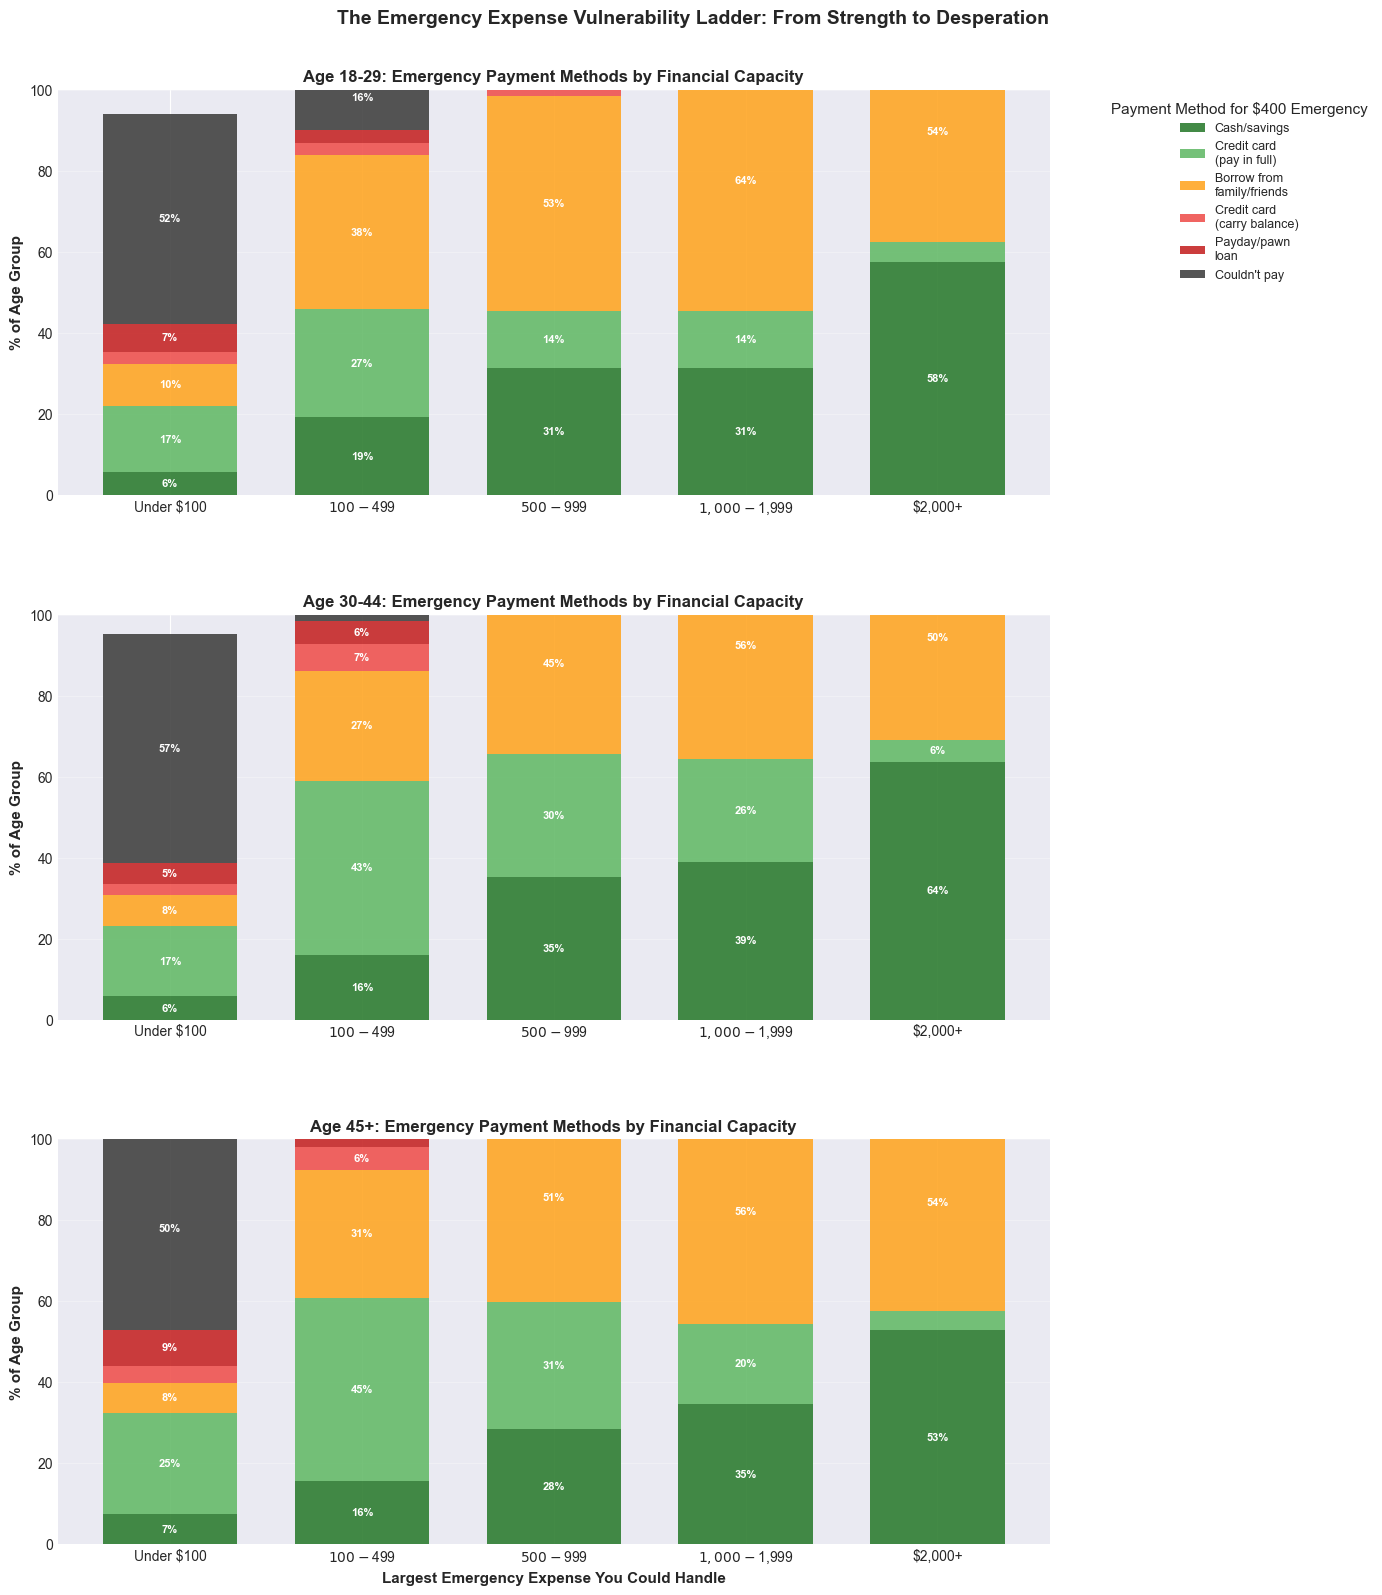


=== KEY INSIGHT ===
As emergency expense capacity decreases, reliance on high-cost options (payday loans, carrying credit card balances)
and inability to pay increase dramatically. This reveals a precise 'fragility spectrum' from financial strength to desperation.
Those who can handle <$100 emergencies are substantially more likely to be unable to cover a $400 expense at all.


In [36]:
# Create Chart 4: Emergency Expense Vulnerability Ladder
# Create 3 subplots for each age group
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

capacity_order = ['Under $100', '$100-$499', '$500-$999', '$1,000-$1,999', '$2,000+']
payment_labels = list(payment_methods.values())

# Define colors for payment methods (gradient from good to bad)
payment_colors = {
    'Cash/savings': '#2E7D32',  # Dark green (best)
    'Credit card\n(pay in full)': '#66BB6A',  # Light green
    'Borrow from\nfamily/friends': '#FFA726',  # Orange
    'Credit card\n(carry balance)': '#EF5350',  # Red
    'Payday/pawn\nloan': '#C62828',  # Dark red
    "Couldn't pay": '#424242'  # Dark gray (worst)
}

for idx, age in enumerate(['18-29', '30-44', '45+']):
    ax = axes[idx]
    age_data = chart4_data[chart4_data['age_group'] == age]
    age_data = age_data.set_index('emergency_capacity').reindex(capacity_order)
    
    # Prepare data for stacked bar
    x = np.arange(len(capacity_order))
    bottom = np.zeros(len(capacity_order))
    
    for payment in payment_labels:
        values = age_data[payment].values
        ax.bar(x, values, bottom=bottom, label=payment, 
               color=payment_colors[payment], alpha=0.9, width=0.7)
        
        # Add percentage labels for values > 5%
        for i, val in enumerate(values):
            if val > 5:
                ax.text(x[i], bottom[i] + val/2, f'{val:.0f}%',
                       ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        
        bottom += values
    
    ax.set_ylabel('% of Age Group', fontweight='bold', fontsize=11)
    ax.set_title(f'Age {age}: Emergency Payment Methods by Financial Capacity',
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(capacity_order)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    if idx == 0:
        ax.legend(title='Payment Method for $400 Emergency', 
                 bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

axes[-1].set_xlabel('Largest Emergency Expense You Could Handle', fontweight='bold', fontsize=11)

fig.suptitle('The Emergency Expense Vulnerability Ladder: From Strength to Desperation',
             fontweight='bold', fontsize=14, y=0.995)

plt.tight_layout()
plt.show()

print("\n=== KEY INSIGHT ===")
print("As emergency expense capacity decreases, reliance on high-cost options (payday loans, carrying credit card balances)")
print("and inability to pay increase dramatically. This reveals a precise 'fragility spectrum' from financial strength to desperation.")
print("Those who can handle <$100 emergencies are substantially more likely to be unable to cover a $400 expense at all.")

---
## Summary: Strategic Insights for Private Sector Leaders

### Key Findings

#### 1. **The Alternative Economy Pipeline is Real and Measurable**
- Credit market exclusion (denial, fear of rejection) directly drives alternative financial service usage
- This represents a quantifiable "exclusion tax" paid by vulnerable populations
- **Opportunity**: Fair lending products, credit-building tools, pathways back to mainstream banking

#### 2. **Retirement Account Raids Follow a Predictable Stress Sequence**
- Lack of emergency savings + bill payment struggles = high likelihood of raiding retirement
- This reveals intervention points BEFORE irreversible damage occurs
- **Opportunity**: Emergency savings programs, income smoothing products, employer financial wellness initiatives

#### 3. **Healthcare Cost Barriers Cascade and Compound**
- People who skip one type of healthcare are substantially more likely to skip others
- Healthcare vulnerability is systemic, not service-specific
- **Opportunity**: Bundled healthcare payment solutions, benefit package design, healthcare-specific credit products

#### 4. **Financial Fragility Exists on a Spectrum**
- Emergency expense capacity precisely predicts coping mechanisms from strength to desperation
- This creates targetable segments for intervention at different vulnerability levels
- **Opportunity**: Tiered emergency savings products, targeted financial assistance, precise customer segmentation

### Why This Matters

These findings reveal that economic vulnerability operates through interconnected systems, not isolated incidents. Understanding these relationships enables:

1. **Better Product Design**: Products that address relationship patterns, not just individual pain points
2. **Earlier Intervention**: Identifying warning signs before crisis behaviors emerge
3. **Market Segmentation**: Precise targeting based on vulnerability profiles, not demographics alone
4. **Impact Measurement**: Understanding which interventions break destructive cycles vs. those that merely shift burden

The widespread nature of these vulnerabilities - across age groups and stress levels - underscores that technological promises of abundance have not translated into financial security for a substantial portion of working Americans. This gap represents both a societal challenge and a market opportunity for solutions that genuinely address underlying systemic issues.